In [ ]:
############################################################################
#### Many Qubits in a cavity ###############################################
############################################################################

In [ ]:
# Generate sets of differential equations for single qubits and multiple qubits in a cavity up to n'th operator order using the hierarchical equations of motion approach
# Finally use cumulants to make the problem solvable
include("operator_terms.jl")
include("combinatorics.jl")
include("cumulants.jl")
include("diff_Eq.jl")
include("preprocessing.jl")
include("preprocessing2.jl")
include("indexing.jl")
include("initial_states.jl")
include("pulses.jl")
include("sampled_integrals.jl")
include("diff_Eq_solver.jl")
include("density_matrices.jl")
include("plotting.jl")
include("saving.jl")
println("Included all files")
using Random 
using BenchmarkTools
rng = MersenneTwister(1234)

In [ ]:
# Pulse parameters ---------------------------------------------------------------------------
rng = MersenneTwister(1234)
max_A::Float64 =  2000.0
T::Float64 = 10
n_t::Int = 500
n::Int = 10
n_comp::Int = 3
pulse_param::Pulse_Param_Struct = Random_Pulse_Param_Wurst(max_A, T, n, rng=rng, how_many=n_comp, omega_min=0.5, normalize_omega=false)
wurst_pulses = wurst_pulse_generator(pulse_param)
# --- System Parameters ----------------------------------------------------------------------
# Gamma is Purcell decay rate, gamma is the spin dephasing rate, kappa is the cavity decay rate
val_dict::Dict = Dict("\\beta" => wurst_pulses, "\\Gamma" => 2*pi*0.0, "\\gamma" => 2*pi*0.0, "\\kappa" => 2*pi*0.05) 

fig = plot_pulse_fourier(val_dict, pulse_param; num_stds=4.0, n=2^10, type=:positive, ops=:all, factor=1e6, base_unit="Hz")
save_fig(fig, "wurst_pulse_T_$(T)_n_$(n_comp)_A_$(max_A)")

In [ ]:
# --- Samples and Weights --------------------------------------------------------------------
var_strs = ["g", "\\Delta"]
order = 5
sample_order = [order, order] #
extra_samples = [1, 1]
total_order = sample_order.*2 .+extra_samples
g0 = 2*pi*150/10^6  # 150Hz
delta_g = g0*0.20
delta0 = 0.0
delta_delta = 2*pi*0.1 # 100kHz 
sigmas = 2.5
N = 10^5
type = :equidistant
    
gaussian = (x, mu, sigma) -> exp(-(x-mu)^2/sigma^2/2)*1/sqrt(2*pi*sigma^2)
prob_fun_vec = [x -> gaussian(x, g0, delta_g), x -> gaussian(x, delta0, delta_delta)]
range_vec = [[g0-sigmas*delta_g, g0+sigmas*delta_g], [-delta_delta*sigmas, delta_delta*sigmas]]
samples = prepare_samples_and_weights(prob_fun_vec, var_strs, ["g"], N, range_vec, sample_order; prepare_analysis=1, type=type, max_comb_order=-1, reltol=1e-15, abstol=1e-15, extra_points=extra_samples, weighted=true)
fig = plot_weighted_locations_2D(samples, "g", strokewidth=0.5, ms=20)
save_fig(fig, "sampled_locations_$(total_order)")
display(fig)
vals2coeffs  = samples.vals2coeffs
coeffs2vals  = samples.coeffs2vals
fprintln("Fit Matrix Deviation: ", maximum(vals2coeffs * coeffs2vals - Diagonal(ones(size(vals2coeffs, 1)))), " at n=", length(samples.locations), " samples.")

In [ ]:
max_order = 3
spin_order = 2
less_spins = max_order-spin_order
is_pauli = false 
print_equations = true
all_eqs = prepare_indexed_eqs_from_samples(max_order, samples, do_lower_order_cumulants=false, less_spins=less_spins, only_prepare=true, is_pauli=is_pauli)
if print_equations
    for eq in all_eqs 
        display(eq)
    end
end

In [6]:
# Function draft for getting the number of combinations
is_pauli = false
spin_combs = geq_spin_combinations(2, is_pauli=is_pauli)
spin_terms = make_terms(spin_combs, is_pauli=is_pauli)
all_eqs = [time_derivative_expectation_of_operator_multispin(op) for op in spin_terms]
how_many_total = prepare_all_exp_op_vector(all_eqs, 10)[1]

465

In [ ]:
# --- Generate all equations and terms --------------------------------------------------------
system = prepare_indexed_eqs_from_samples(max_order, samples, do_lower_order_cumulants=true, less_spins=less_spins, printing=true, is_pauli=is_pauli, threaded=false)
println("")

---- Generating Indexed Differential Equations of Order 4 with max. spin order 3 and 144 samples ----


In [7]:
# --- Initial Conditions ---------------------------------------------------------------------
param_generator, constant_value_indexes = value_generator(pulse_param, val_dict, system) # Pulse Values
spin_param = Dict("N" => N, "A" => 1.0, "phi" => 0.0)#even_odd_vector(samples, :even, :complex, rng=MersenneTwister(1234)))
#spin_param = Dict("N" => N, "A" => 1.0, "phi" => weighted_vector(samples, [1,1], [0,0]))
cavity_param = Dict("alpha" => 0.0, "Theta" => 0.0)
initial_conditions = operators2initialstates(system, samples, "single_non_excitation", "coherent", spin_param, cavity_param)
println("Done preparing initial conditions")

Done preparing initial conditions


In [8]:
# --- Solving the System ---------------------------------------------------------------------
diff_problem = DifferentialProblem(param_generator, system, samples)  # all_eqs_indexed_reduced
solution = evolve_system(initial_conditions, diff_problem, T, reltol=1e-8, abstol=1e-8, threaded=true, print_dt=T/10, reduced_save=true) 
#solution_final = evolve_system_final(initial_conditions, diff_problem, T, dt=0.5, solvetype=:Vern9, reltol=10.0, abstol=1e-13, threaded=true, print_dt=T/20)
println("Done")

   0.0/10.0 ( Elapsed: 00:03 - Remaining: ∞ ) | Its.: 1
   1.0/10.0 ( Elapsed: 00:15 - Remaining: 02:18 ) | Its.: 899
   2.0/10.0 ( Elapsed: 00:27 - Remaining: 01:48 ) | Its.: 1765
   3.0/10.0 ( Elapsed: 00:35 - Remaining: 01:23 ) | Its.: 2403
   4.0/10.0 ( Elapsed: 00:42 - Remaining: 01:03 ) | Its.: 2895
   5.0/10.0 ( Elapsed: 00:46 - Remaining: 00:46 ) | Its.: 3181
   6.1/10.0 ( Elapsed: 00:49 - Remaining: 00:32 ) | Its.: 3391
   7.1/10.0 ( Elapsed: 00:53 - Remaining: 00:22 ) | Its.: 3650
   8.1/10.0 ( Elapsed: 00:57 - Remaining: 00:13 ) | Its.: 3972
   9.1/10.0 ( Elapsed: 01:01 - Remaining: 00:06 ) | Its.: 4257
  10.0/10.0 ( Elapsed: 01:05 - Remaining: 00:00 ) | Its.: 4494
Done


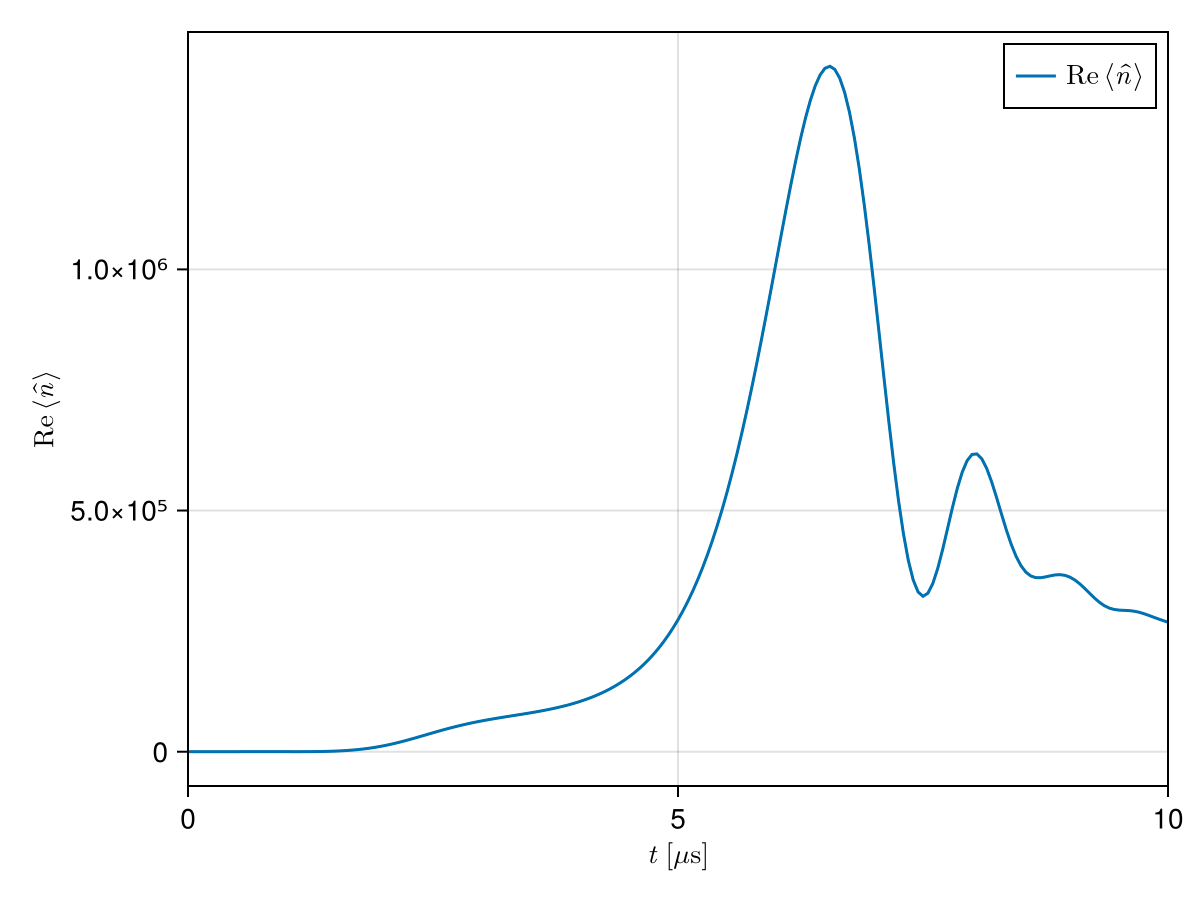

In [9]:
op_str = "+-"
opstr = "real"
plottype="x"
fig = plot_expectation_values_over_t(op_str, solution, plottype=plottype, opstr=opstr, plot_trajectories=true, clamps=false)
save_fig(fig, "expectation_values_$(opstr)_$(op_str)_T_$(T)_$(plottype)_$(total_order)")

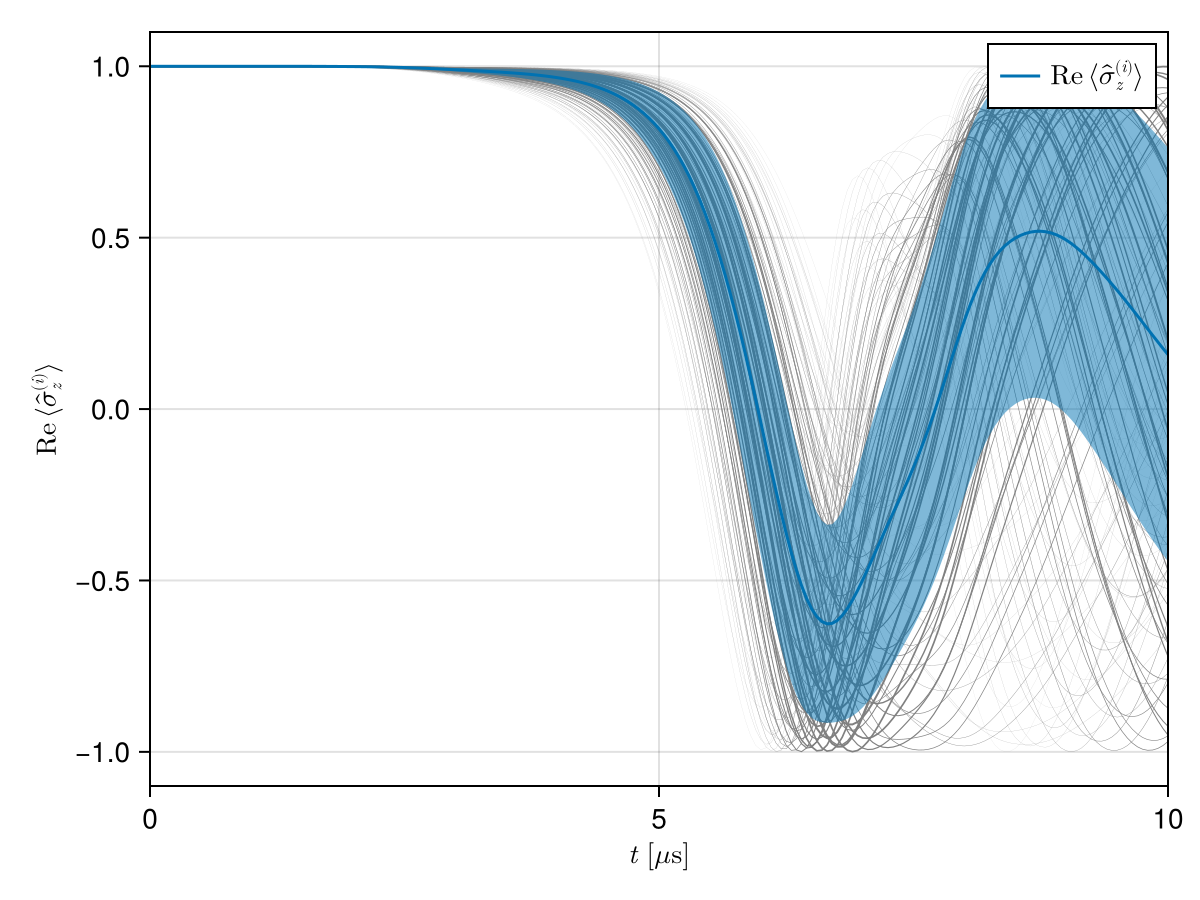

In [10]:
op_str = "z"
opstr = "real"
plottype="x"
fig = plot_expectation_values_over_t(op_str, solution, plottype=plottype, opstr=opstr, plot_trajectories=true, clamps=false)
save_fig(fig, "expectation_values_$(opstr)_$(op_str)_T_$(T)_$(plottype)_$(total_order)")

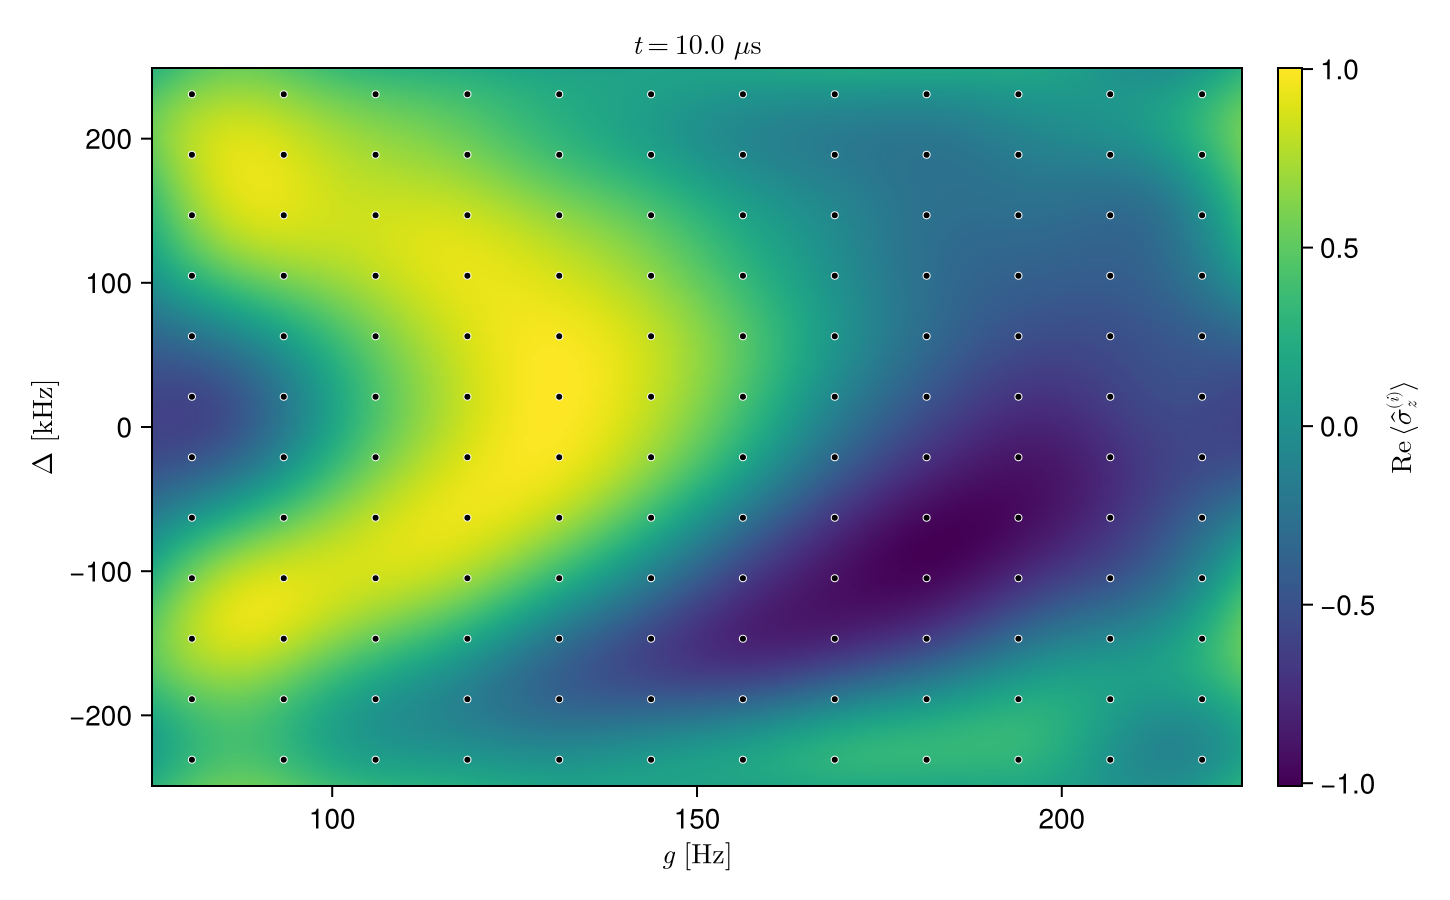

In [11]:
op_str = "z"
weighted = false
plottype = "x"
fig, curr_t_rounded = plot_operator_as_function_2D(op_str, solution, res=250, rel_range=2/2, rel_col_range=1.0, weighted=weighted, plottype=plottype, do_locations=true, t=-2, do_title=true)
save_fig(fig, "operator_as_function_2D_z_T_$(T)_order_$(sample_order)_$(plottype)_weighted_$(weighted)_t_$(curr_t_rounded)_$(total_order)")

In [12]:
# Make movie of time evolution 
weighted = false
plot_operator_as_function_2D_in_t("order_$(sample_order)_$(plottype)_weighted_$(weighted)_$(total_order)", op_str, solution, res=250, rel_range=2/2, rel_col_range=1.0, weighted=weighted, plottype=plottype, do_locations=true, do_title=true)

Preparing the maps (n=201)
Creating the Plots
Creating Movie
Done


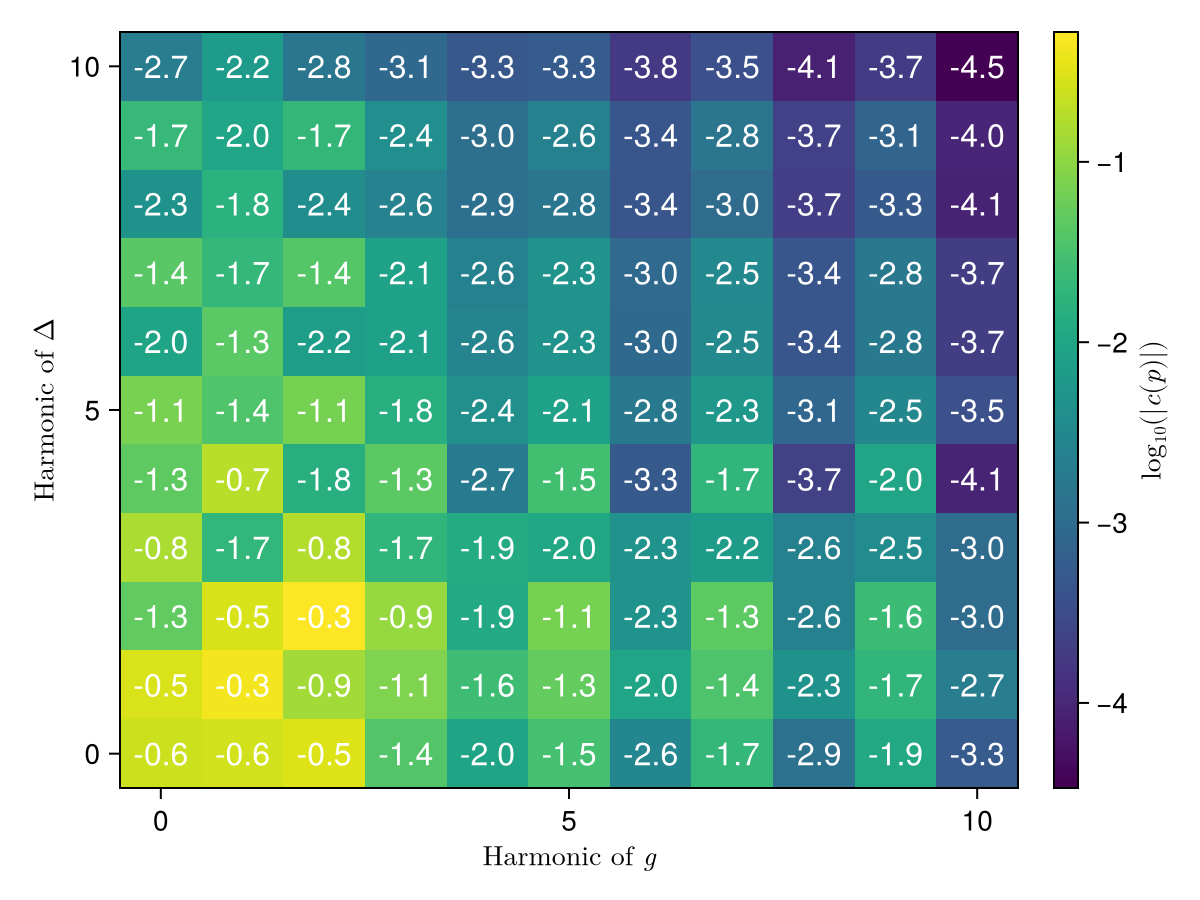

In [13]:
fig = plot_basis_function_coeffs_2D(op_str, solution, t=9.0)
save_fig(fig, "operator_basis_coeffs_2D_z_T_$(T)_order_$(sample_order)_$(plottype)_weighted_$(weighted)_t_$(curr_t_rounded)_$(total_order)")

In [15]:
# a function, that finds the first indexes and cavity operators for a spin operator. 
function spin_str2cavity_index_dict(system::SystemAndDicts, spin_str::String, max_cavity_order::Int=2)::Tuple{Dict{String, Int}, Int}
    # returns the indexes for every cavity operator with given spin operator
    # also returns how_many spin index combinations exist for the given spin operator
    operator_strings_dict = system.operator_strings_dict
    cavity_strings_dict::Dict{String, Int} = Dict()
    if length(spin_str) == 0
        how_many = 1
    else
        how_many = operator_strings_dict[spin_str].how_many
    end
    # cavity operator strings 
    for order in 0:max_cavity_order
        for p in 0:floor(Int, order/2)
            q = order - p
            curr_cavity_str = "+"^p * "-"^q
            total_str = curr_cavity_str * spin_str
            if length(total_str) == 0
                cavity_strings_dict[curr_cavity_str] = -1
            elseif haskey(operator_strings_dict, total_str)
                cavity_strings_dict[curr_cavity_str] = operator_strings_dict[total_str].first_index
            else
                error("Operator string $total_str not found in the system.")
            end
        end
    end
    return cavity_strings_dict, how_many
end
## Test the function
#cavity_strings_dict, how_many = spin_str2cavity_index_dict(system, "z", 2)

function spin_str2cavity_indexes(system::SystemAndDicts, spin_str::String, max_cavity_order::Int=2)
    # returns the indexes for every cavity operator with given spin operator
    # also returns how_many spin index combinations exist for the given spin operator
    operator_strings_dict = system.operator_strings_dict
    cavity_strings::Vector{String} = []
    cavity_indexes::Vector{Int} = []
    if length(spin_str) == 0
        how_many = 1
    else
        how_many = operator_strings_dict[spin_str].how_many
    end
    # cavity operator strings 
    for order in 0:max_cavity_order
        for p in 0:floor(Int, order/2)
            q = order - p
            curr_cavity_str = "+"^p * "-"^q
            total_str = curr_cavity_str * spin_str
            if length(total_str) == 0
                push!(cavity_strings, curr_cavity_str)
                push!(cavity_indexes, -1)
            elseif haskey(operator_strings_dict, total_str)
                push!(cavity_strings, curr_cavity_str)
                push!(cavity_indexes, operator_strings_dict[total_str].first_index)
            else
                error("Operator string $total_str not found in the system.")
            end
        end
    end
    return cavity_strings, cavity_indexes, how_many
end
## Test the function
#cavity_strings, cavity_indexes, how_many = spin_str2cavity_indexes(system, "z", 2)

spin_str2cavity_indexes (generic function with 2 methods)

In [16]:
function get_values_at_T(solution::DifferentialSolution, indexes::Vector{Int})
    # if indexes[1] =-1 then the value is 1 
    vals::Vector{ComplexF64} = Vector{ComplexF64}(undef, length(indexes))
    if indexes[1] == -1
        vals[1] = 1.0
        vals[2:end] = solution.vals[end][indexes[2:end]]
    else
        vals = solution.vals[end][indexes]
    end
    return vals
end

get_values_at_T (generic function with 1 method)

In [13]:
cavity_strings, p_cavity_indexes, p_how_many = spin_str2cavity_indexes(system, "p", 2)
index_add = 0
p_vals = get_values_at_T(solution, p_cavity_indexes .+ index_add)
p = p_vals[1]
p_alpha = p_vals[2]/p
p_n = p_vals[4]/p
z_cavity_indexes, z_how_many = spin_str2cavity_indexes(system, "z", 2)[2:end]
z_vals = get_values_at_T(solution, z_cavity_indexes .+ index_add)
z = z_vals[1]
z_alpha = z_vals[2]/z
z_n = z_vals[4]/z
cavity_indexes, how_many = spin_str2cavity_indexes(system, "", 2)[2:end]
vals = get_values_at_T(solution, cavity_indexes)
_alpha = vals[2]
_n = vals[4]
# 1 + z => |1> and 1 - z => |0>


35878.50470544272 + 7.655395275141627e-14im

In [14]:
# eigenvalue of p matrix 
p = [0 1; 0 0]
p_eigenvalues = eigvecs(p)

2×2 Matrix{Float64}:
 1.0  -1.0
 0.0   2.00417e-292

In [15]:
println(abs(_n), " ", abs(z_n), " ", abs(p_n)) 

35878.50470544272 35879.53799168358 35878.142607476715


In [16]:
samples.weights_dict

Dict{String, Vector{Float64}} with 2 entries:
  "g" => [8.3908, 8.3908, 4.05009, 4.05009, 0.850484, 0.850484, 9.92615, 9.9261…
  ""  => [0.0971745, 0.0971745, 0.0469044, 0.0469044, 0.00984951, 0.00984951, 0…

In [17]:
cavity_strings

4-element Vector{String}:
 ""
 "-"
 "--"
 "+-"

In [18]:
cavity_strings, cavity_indexes, how_many = spin_str2cavity_indexes(system, "z", 2)
index_add = 0
t_ind = 100
vals = solution.vals[70][cavity_indexes .+ index_add]
z = vals[1]
m = vals[2]/z # alpha_z = <-z>/<z>   
mm = vals[3]/z # 
pm = vals[4]/z
println("z: ", z)
println("m: ", m)
println("mm: ", mm, " rel. error: ", abs(m*m - mm)/abs(mm))
println("pm: ", pm, " rel. error: ", abs(m*conj(m) - pm)/abs(pm))

z: 0.9989687363644866 + 0.0im
m: 40.85856578128006 + 57.24065962541842im
mm: -1607.0707552702656 + 4677.54247591696im rel. error: 1.0872844364962473e-8
pm: 4946.174087408585 - 3.203594448938456e-15im rel. error: 5.227785108641208e-5


In [42]:
# Test the density matrix 
p = [0 1; 0 0]
z = [1 0; 0 -1]
I = [1 0; 0 1]
# generate single qubit density matrix (random)
rho = rand(ComplexF64, 2, 2)
rho = rho + rho'
rho = rho/tr(rho)
exp_p = tr(rho*p)
exp_z = tr(rho*z)
#println("Expectation values: ", exp_p, " ", exp_z)
# reconstruct matrix 
rho_reconstructed = 1/2*(I + 2*conj(exp_p)*p + 2*(exp_p)*p' + exp_z*z)
println("Reconstruction error: ", norm(rho - rho_reconstructed))

Reconstruction error: 0.11939215126879055


In [73]:
# now two qubits 
II = kron(I, I)
pI = kron(p, I)
Ip = kron(I, p)
pp = kron(p, p)
pm = kron(p, p')
pz = kron(p, z)
zp = kron(z, p)
zI = kron(z, I)
Iz = kron(I, z)
zz = kron(z, z)
rho = rand(ComplexF64, 4,4)
rho = rho + rho'
rho = rho/tr(rho)
exp_pI = conj(tr(rho*pI))
exp_Ip = conj(tr(rho*Ip))
exp_pp = conj(tr(rho*pp))
exp_pm = conj(tr(rho*pm))
exp_pz = conj(tr(rho*pz))
exp_zp = conj(tr(rho*zp))
exp_zI = conj(tr(rho*zI))
exp_Iz = conj(tr(rho*Iz))
exp_zz = conj(tr(rho*zz))
rho_reconstructed = 1/4*(II + 2*exp_pI*pI + 2*conj(exp_pI)*pI' + 2*exp_Ip*Ip + 2*conj(exp_Ip)*Ip'+ 4*exp_pp*pp + 4*conj(exp_pp)*pp' + 4*exp_pm*pm + 4*conj(exp_pm)*pm' + 2*exp_pz*pz + 2*conj(exp_pz)*pz' + 2*exp_zp*zp + 2*conj(exp_zp)*zp' + exp_zI*zI + exp_Iz*Iz + exp_zz*zz)
println("Reconstruction error: ", norm(rho - rho_reconstructed))

Reconstruction error: 8.355534721610419e-17


In [40]:
# Test the density matrix 
x = [0 1; 1 0]
y = [0 -im; im 0]
z = [1 0; 0 -1]
I = [1 0; 0 1]
# generate single qubit density matrix (random)
rho = rand(ComplexF64, 2, 2)
rho = rho + rho'
rho = rho/tr(rho)
exp_x = tr(rho*x)
exp_y = tr(rho*y)
exp_z = tr(rho*z)
#println("Expectation values: ", exp_p, " ", exp_z)
# reconstruct matrix 
rho_reconstructed = 1/2*(I + exp_x*x + exp_y*y + exp_z*z)
println("Reconstruction error: ", norm(rho - rho_reconstructed))

Reconstruction error: 1.2412670766236366e-16


In [167]:
values_at_t("-z", solution, t=-2)[1]

In [125]:
determine_indexes = determine_multi_indexes_gen(10, 2)[1]
determine_indexes(Vector{Vector{Int}}([[3],[],[10]]))

30

In [103]:
system.operator_strings_dict["z"].how_many

36

In [ ]:
include("density_matrices.jl")

make_density_matrix_printing (generic function with 1 method)

In [123]:
function all_indexed_spin_and_cavity_operators(order::Int, is_pauli::Bool; do_minus::Bool=true, less_spins::Int=1)
    # create also all ordered combinations of + and - for the cavity (with number of + <= number of -)
    # Returns the different possible index combinations for the operators, 
    # then a dictionary, with the index combinations as values and the operator as key (negative signs indicate conjugates of operators), 
    # finally a list of the operators
    if less_spins < 2 && !do_minus
        error("less_spins < 2 and do_minus=false, this will not give any cavity operators")
    end
    spin_order = order - less_spins
    index_combinations, spin_index_combinations, spins_list = all_indexed_spin_operators(spin_order, is_pauli)
    # for every spin index combination, add all combinations of -, +-, -- etc. for the cavity
    cavity_spin_index_combinations = Dict{String,Vector{Int}}()
    string_combinations::Vector{String} = []
    if do_minus
        cavity_combinations = ["", "-", "+-"]
        if !is_pauli 
            error("Not implemented: do_minus=true and is_pauli=false, as such cavity operators themselves are not their own conjugate -> different implementation needed.")
        end
    else
        cavity_combinations = ["", "+-"]
    end
    for c in cavity_combinations
        for spin_comb in spins_list
            spin_index_pre = spin_index_combinations[spin_comb]
            #spin_index = abs.(spin_index_pre)
            #conjugates = spin_index_pre .< 0
            curr_spin_order = length(spin_comb)
            new_string = c * spin_comb
            cavity_spin_index_combinations[new_string] = spin_index_pre
            push!(string_combinations, new_string)
        end
    end
    return index_combinations, cavity_spin_index_combinations, string_combinations
end
## Test 
all_indexed_spin_and_cavity_operators(3, false)

([Int64[], [2], [1], [1, 2], [2, 1]], Dict("+-pm" => [4, 5], "+-pp" => [4, -4], "zz" => [4], "+-" => [1], "+-p" => [2, -2, 3, -3], "pz" => [4, -4, 5, -5], "pm" => [4, 5], "z" => [2, 3], "+-pz" => [4, -4, 5, -5], "+-zz" => [4]…), ["", "p", "z", "pp", "pm", "pz", "zz", "+-", "+-p", "+-z", "+-pp", "+-pm", "+-pz", "+-zz"])

In [27]:
# Test 
density_matrices, matrix_generator = Density_Matrix_Generator(system, samples)
solution_initial = calc_cumulants(initial_conditions, system)
sqrt_rho0 = sqrt(make_density_matrix(density_matrices[1], matrix_generator, solution_initial))

sigma = make_density_matrix(density_matrices[1], matrix_generator, solution_final)
Infidelity_from_expectation_values(sigma, sqrt_rho0)

UndefVarError: UndefVarError: `system` not defined

In [29]:
order = system.order
spin_order = system.spin_order
println(order, " ", spin_order)

3 2


In [30]:
system

SystemAndDicts(DE_Term_indexed[DE_Term_indexed(1, Indexed_Term[Indexed_Term(101, false, 1, 0.15866629563584814 - 0.0im), Indexed_Term(45652, false, 1, 0.0 + 0.0008948779073861834im), Indexed_Term(45652, true, 1, 0.0 - 0.0008948779073861834im), Indexed_Term(1, false, 2, -1.0 + 0.0im), Indexed_Term(1, false, 3, -0.5 - 0.0im)], Indexed_Term[], Constant_Term[], true), DE_Term_indexed(2, Indexed_Term[Indexed_Term(102, false, 1, -0.15866629563584814 + 0.0im), Indexed_Term(45653, false, 1, 0.0 + 0.0008948779073861834im), Indexed_Term(45653, true, 1, 0.0 - 0.0008948779073861834im), Indexed_Term(2, false, 2, -1.0 + 0.0im), Indexed_Term(2, false, 3, -0.5 - 0.0im)], Indexed_Term[], Constant_Term[], true), DE_Term_indexed(3, Indexed_Term[Indexed_Term(103, false, 1, 0.47599888690754444 - 0.0im), Indexed_Term(45654, false, 1, 0.0 + 0.0008948779073861834im), Indexed_Term(45654, true, 1, 0.0 - 0.0008948779073861834im), Indexed_Term(3, false, 2, -1.0 + 0.0im), Indexed_Term(3, false, 3, -0.5 - 0.0im)], 

In [20]:
# A function that optimizes a weight vector for the samples to find dark states
function find_dark_state(T::Float64, system::SystemAndDicts, samples::SamplesAndWeights, val_dict::Dict, pulse_param::Pulse_Param_Struct)
    param_generator, constant_value_indexes = value_generator(pulse_param, val_dict, system) # Pulse Values
    order_comb = samples.order_comb
    function initial_conditions_from_order_comb_weights(order_comb_weights::Vector{T}) where T
        order_comb_with_weights::Vector{Tuple{Vector{Int}, T}} = collect(zip(order_comb, order_comb_weights))
        spin_param = Dict("N" => 10^6, "A" => 1.0, "phi" => weighted_vector(samples, order_comb_with_weights))
        cavity_param = Dict("alpha" => 0.0, "Theta" => 0.0)
        initital_conditions = operators2initialstates(system, samples, "single_non_excitation", "coherent", spin_param, cavity_param)
        return initital_conditions
    end
    # Optimize the system 
    solution_final = evolve_system_final(initial_conditions, diff_problem, T, dt=0.5, solvetype=:Vern9, reltol=10.0, abstol=1e-13)

Base.Meta.ParseError: ParseError:
# Error @ c:\Users\micha\Desktop\PhD\Research\Projects\DD_Inhomogenously_Broadened_Spin_Ensemble\Julia\test_DE_Multi_optimization.ipynb:13:131
    # Optimize the system 
    solution_final = evolve_system_final(initial_conditions, diff_problem, T, dt=0.5, solvetype=:Vern9, reltol=10.0, abstol=1e-13)
#                                                                                                                                 └ ── Expected `end`

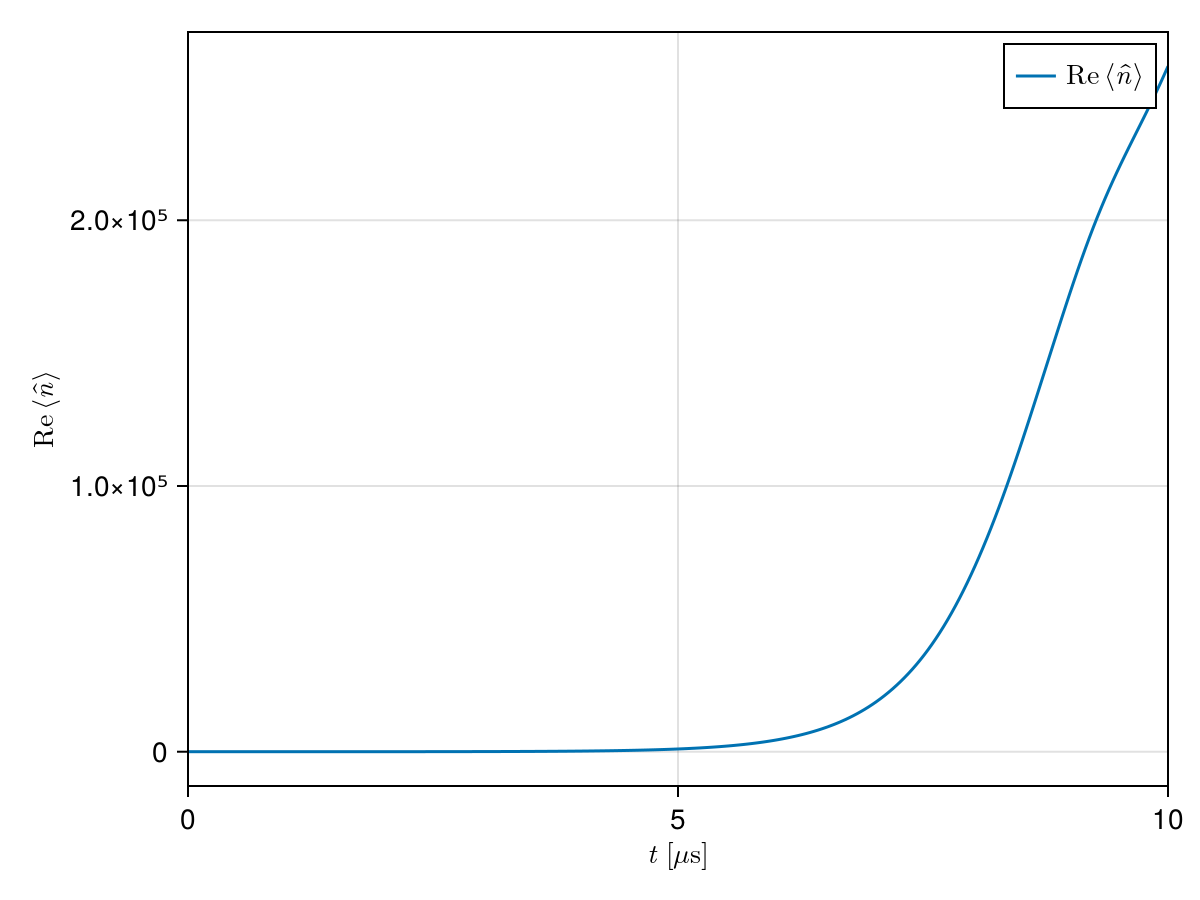

In [12]:
op_str = "+-"
opstr = "real"
plottype="x"
fig = plot_expectation_values_over_t(op_str, solution, system, samples, plottype=plottype, opstr=opstr, plot_trajectories=false, clamps=false)
save_fig(fig, "expectation_values_$(opstr)_$(op_str)_T_$(T)_$(plottype)")

In [ ]:
op_str = "zz"
opstr = "real"
plottype="x"
fig = plot_expectation_values_over_t(op_str, solution, system, samples, plottype=plottype, opstr=opstr, clamps=false, do_ribbon=true, do_mean=true, plot_sampled_stat=false, plot_trajectories=true)
save_fig(fig, "expectation_values_$(opstr)_$(op_str)_T_$(T)_$(plottype)")

In [ ]:
fig = plot_cumulants_vs_cumulant_expansion("zz", solution, system, samples, opstr="real", plottype="x", difference=true, trajectories=true)

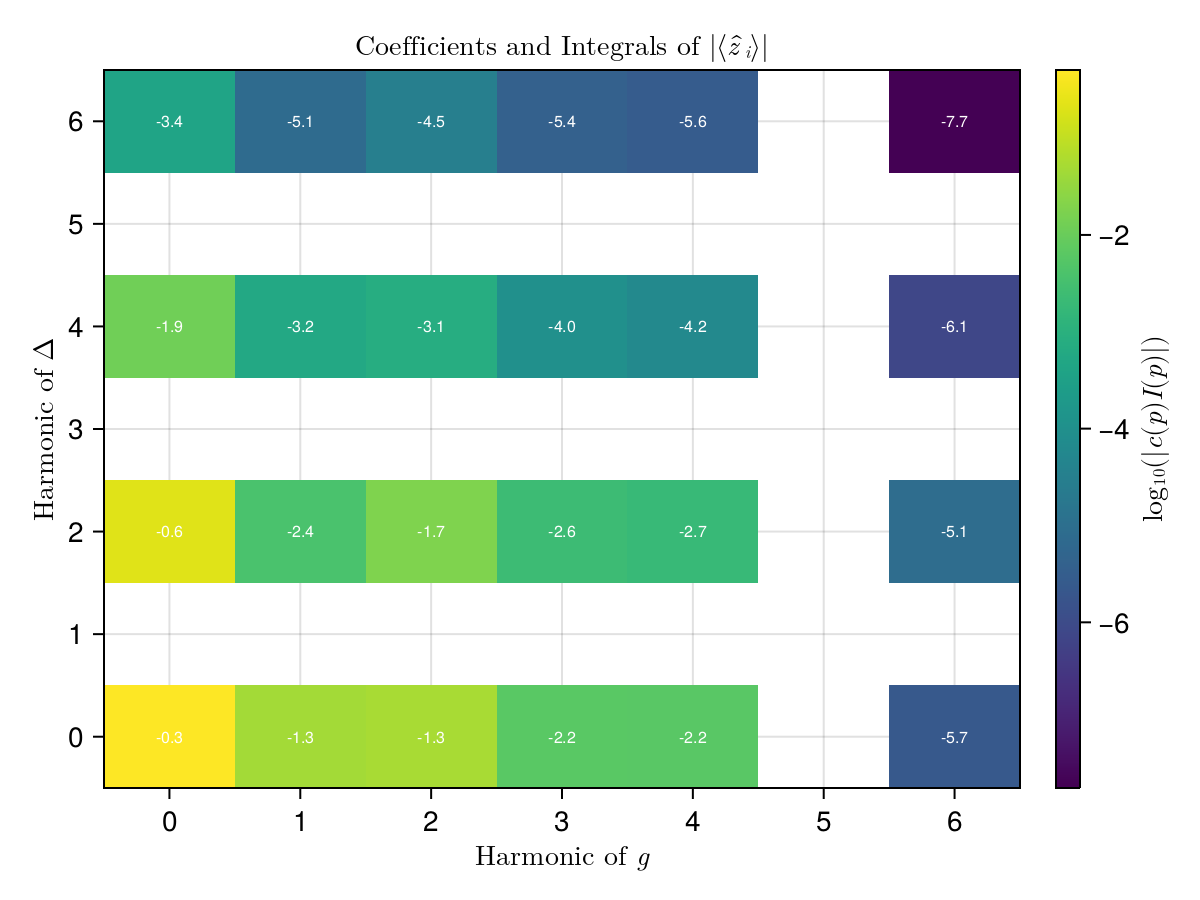

In [15]:
op_str = "z"
plottype = "coeffs_integrals"
fig = plot_basis_function_coeffs_2D(op_str, solution, system, samples, plottype=plottype, fontsize=4)
save_fig(fig, "basis_function_coeffs_2D_abs_$(opstr)_$(op_str)_T_$(T)_order_$(sample_order)_$(plottype)")

In [2]:
include("diff_Eq_solver.jl")

evolve_system_final (generic function with 1 method)

In [3]:
max_order = 2
var_strs = ["g", "\\Delta"]
sample_order = [15, 15] # [12,12] #
g0 = 2*pi*150/10^6  # 150Hz
delta_g = g0*0.20
delta0 = 0.0
delta_delta = 2*pi*0.1 # 100kHz 
sigmas = 3.0
N = 10^6

circle = false      # If true, the samples are drawn from a circle, if false, they are drawn from a square      
gaussian = (x, mu, sigma) -> exp(-(x-mu)^2/sigma^2/2)*1/sqrt(2*pi*sigma^2)
prob_fun_vec = [x -> gaussian(x, g0, delta_g), x -> gaussian(x, delta0, delta_delta)]
range_vec = [[g0-sigmas*delta_g, g0+sigmas*delta_g], [-delta_delta*sigmas, delta_delta*sigmas]]
samples = prepare_samples_and_weights(prob_fun_vec, var_strs, ["g"], N, range_vec, sample_order; prepare_analysis=1, max_comb_order=-1, on_borders=false, circle=circle, reltol=1e-15, abstol=1e-15, extra_points=0)
fig = plot_weighted_locations_2D(samples, "g", strokewidth=0.5, ms=20)

# Pulse parameters ---------------------------------------------------------------------------
max_A::Float64 = 0.0
T::Float64 = 18
n_t::Int = 250
how_many::Int = 1
pulse_param::Pulse_Param_Struct = Random_Pulse_Param_Sin(max_A, T, rng=rng, how_many=how_many)
sin_pulses = sin_pulse_generator(pulse_param)
val_dict::Dict = Dict("\\beta" => sin_pulses, "\\Gamma" => 2*pi*0.0, "\\gamma" => 2*pi*0.0, "\\kappa" => 2*pi*0.05) # Gamma is Purcell decay rate, gamma is the spin dephasing rate, kappa is the cavity decay rate
# --- Generate all equations and terms --------------------------------------------------------
system = prepare_indexed_eqs_from_samples(max_order, samples, do_lower_order_cumulants=true, less_spins=1, printing=true)

# --- Initial Conditions ---------------------------------------------------------------------
param_generator, constant_value_indexes = value_generator(pulse_param, val_dict, system) # Pulse Values
spin_param = Dict("N" => 10^6, "A" => 1.0, "phi" => 0.0)#even_odd_vector(samples, :even, :complex, rng=MersenneTwister(1234)))
#spin_param = Dict("N" => 10^6, "A" => 1.0, "phi" => weighted_vector(samples, [1,1], [0,0]))
cavity_param = Dict("alpha" => 0.0, "Theta" => 0.0)
initial_conditions = operators2initialstates(system, samples, "single_non_excitation", "coherent", spin_param, cavity_param)
println("Done preparing initial conditions")

# --- Solving the System ---------------------------------------------------------------------
#all_eqs_indexed_reduced = remove_zero_terms(all_eqs_indexed, param_generator, constant_value_indexes; how_many_eps=5)
diff_problem = DifferentialProblem(param_generator, system)  # all_eqs_indexed_reduced
solution = evolve_system(initial_conditions, diff_problem, T, dt=0.5, solvetype=:Vern7, reltol=1e-10, abstol=1e-13, threaded=true, print_dt=T/20)
println("Done")

---- Generating Indexed Differential Equations of Order 2 with max. spin order 1 and 961 samples ----
   # of Equations:     5.769
   # of Cumulants: 3.700.811
Abstract Term Generation completed (00:00)
Term Generation completed (00:00)
   ->  1.387.684/3.700.811 ( Elapsed: 00:01 - Remaining: 00:02 )
   ->  2.777.290/3.700.811 ( Elapsed: 00:05 - Remaining: 00:01 )
   ->  3.700.811/3.700.811 ( Elapsed: 00:08 - Remaining: 00:00 )
Cumulants constructed (00:11)
Lower Order Full Cumulants constructed (00:00)
---- Done -------------------------------------------------------------------------------------------
Done preparing initial conditions
  0.0/18.0 ( Elapsed: 00:02 - Remaining: ∞ )
  0.9/18.0 ( Elapsed: 00:09 - Remaining: 03:05 )
  1.8/18.0 ( Elapsed: 00:15 - Remaining: 02:15 )
  2.7/18.0 ( Elapsed: 00:20 - Remaining: 01:53 )
  3.7/18.0 ( Elapsed: 00:25 - Remaining: 01:38 )
  4.6/18.0 ( Elapsed: 00:29 - Remaining: 01:27 )
  5.5/18.0 ( Elapsed: 00:34 - Remaining: 01:19 )
  6.4/18.0 ( Ela

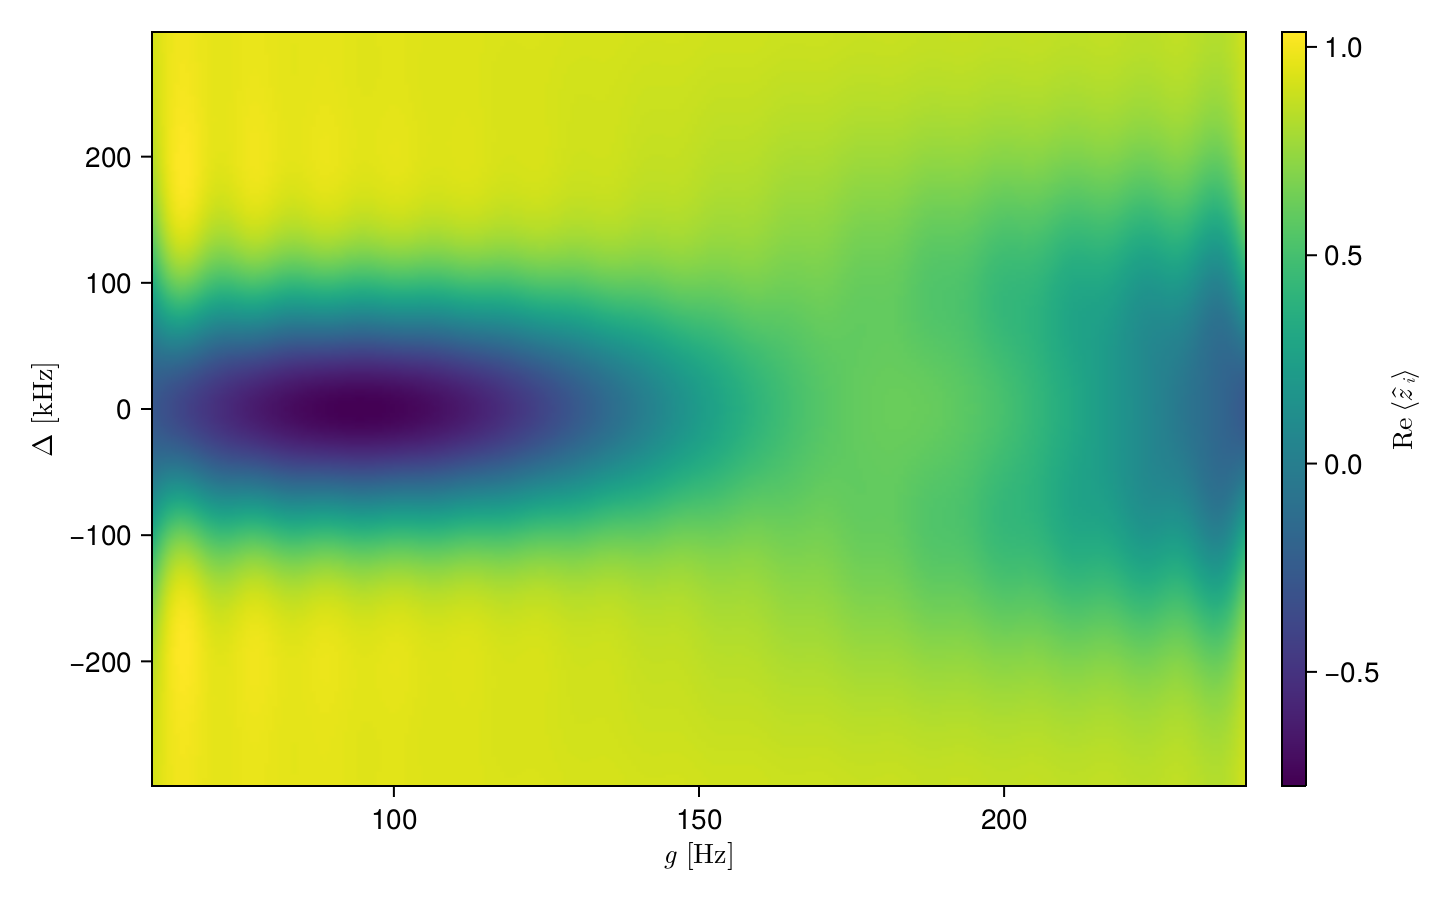

In [4]:
op_str = "z"
weighted = false
plottype = "x"
fig = plot_operator_as_function_2D(op_str, solution, system, samples, res=250, rel_range=2/2, rel_col_range=1.0, weighted=weighted, plottype=plottype, do_red=false)
save_fig(fig, "operator_as_function_2D_z_T_$(T)_order_$(sample_order)_$(plottype)_weighted_$(weighted)")

In [5]:
op_str = "z"
weighted = false
plottype = "x"
plot_operator_as_function_2D_in_t(op_str, solution, system, samples, res=50, rel_range=2/2, rel_col_range=1.0, weighted=weighted, plottype=plottype)